In [2]:
import h5py
import os
import numpy as np
import matplotlib.pyplot as plt

## PtychoPINN results

In [6]:
folder = "/home/beams/HRUTH/code/ptycho_development/CDI-PINN_benchmark/"
files = os.listdir(folder)
files = [file for file in files if "timing_results" in file]
timing_results = {}
for file in files:
    with h5py.File(os.path.join(folder, file)) as F:
        timing_names = list(F["0"].keys())
        run_idx = [int(k) for k in F.keys() if k.isnumeric()]
        data_name = F["data_name"][()].decode()
        timing_results[data_name] = {}
        for name in timing_names:
            timing_results[data_name][name] = []
            for idx in run_idx:
                timing_results[data_name][name] += [F[str(idx)][name][()]]
            timing_results[data_name][name] = np.array(timing_results[data_name][name])


In [7]:
timing_results

{'pinn_velo_ic_2': {'data_load_time': array([5.29123712, 5.29885244, 5.30804873, 5.32563162, 5.31531215,
         5.32758355, 5.32259774]),
  'model_load_time': array([2.6905055 , 2.25489354, 2.29501915, 2.22180629, 2.62100387,
         2.16141748, 2.21616936]),
  'total_assembly_time': array([0.05895305, 0.02608418, 0.03319836, 0.03714013, 0.03078794,
         0.02570891, 0.02537584]),
  'total_inference_time': array([1.04129887, 1.05512142, 1.04251909, 1.04185724, 1.05383635,
         1.03916311, 1.03760242])},
 'pinn_hxn_cnm': {'data_load_time': array([14.72360516, 14.7720654 , 14.73942733, 14.84927535, 14.76166272]),
  'model_load_time': array([2.6829803 , 2.27346444, 2.65094233, 2.33555079, 2.67526579]),
  'total_assembly_time': array([0.05186796, 0.05461335, 0.04939175, 0.04812384, 0.04786158]),
  'total_inference_time': array([1.96264863, 1.95582485, 1.94351649, 1.94779778, 1.95152879])},
 'pinn_velo_fly001': {'data_load_time': array([5.82403708, 5.84528351, 5.85386348, 5.835415

In [8]:
var_names = list(timing_results["pinn_hxn_cnm"].keys())
data_names = list(timing_results.keys())
averages = {}
st_devs = {}

# get average for each one
for var_name in var_names:
    averages[var_name] = []
    st_devs[var_name] = []
    for data_name in data_names:
        averages[var_name] += [timing_results[data_name][var_name].mean()]
        st_devs[var_name] += [timing_results[data_name][var_name].std()]


In [9]:
max_name_len = max(len(name) for name in data_names)

for var_name in var_names:
    print(f"{var_name}:")
    for data_name in data_names:
        mean = timing_results[data_name][var_name].mean()
        std = timing_results[data_name][var_name].std()
        # Use actual ± character
        print(f"    {data_name:<{max_name_len}}  {mean:.2f} ± {std:.2f}s")


data_load_time:
    pinn_velo_ic_2         5.31 ± 0.01s
    pinn_hxn_cnm           14.77 ± 0.04s
    pinn_velo_fly001       5.84 ± 0.01s
    pinn_velo_gold_tp_2    4.16 ± 0.01s
    pinn_cosmic_micro_lfp  3.45 ± 0.35s
    pinn_velo_ncm          1.47 ± 0.19s
    pinn_velo_gold_tp_1    0.60 ± 0.00s
    pinn_velo_ic_1         0.60 ± 0.00s
model_load_time:
    pinn_velo_ic_2         2.35 ± 0.20s
    pinn_hxn_cnm           2.52 ± 0.18s
    pinn_velo_fly001       2.34 ± 0.17s
    pinn_velo_gold_tp_2    2.40 ± 0.20s
    pinn_cosmic_micro_lfp  2.39 ± 0.21s
    pinn_velo_ncm          2.38 ± 0.15s
    pinn_velo_gold_tp_1    2.48 ± 0.27s
    pinn_velo_ic_1         2.29 ± 0.01s
total_assembly_time:
    pinn_velo_ic_2         0.03 ± 0.01s
    pinn_hxn_cnm           0.05 ± 0.00s
    pinn_velo_fly001       0.07 ± 0.07s
    pinn_velo_gold_tp_2    0.02 ± 0.00s
    pinn_cosmic_micro_lfp  0.04 ± 0.03s
    pinn_velo_ncm          0.03 ± 0.01s
    pinn_velo_gold_tp_1    0.04 ± 0.04s
    pinn_velo_ic_1       

In [ ]:
# plot all vars on same plot

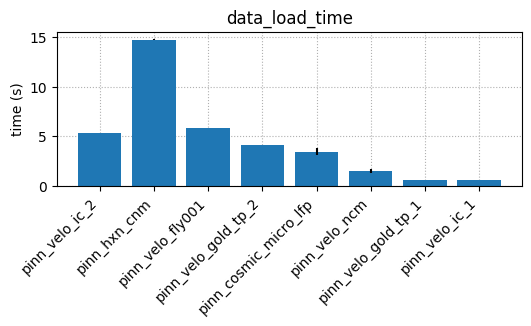

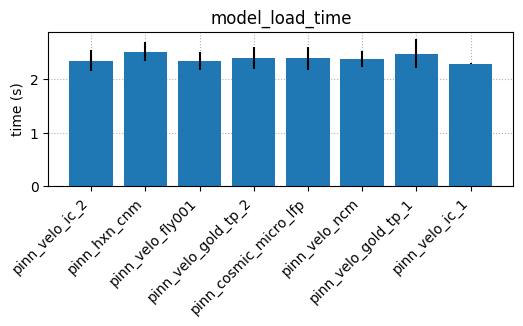

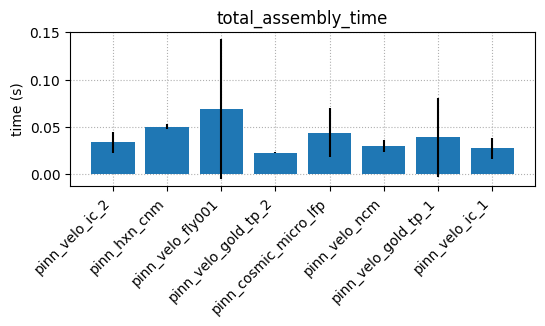

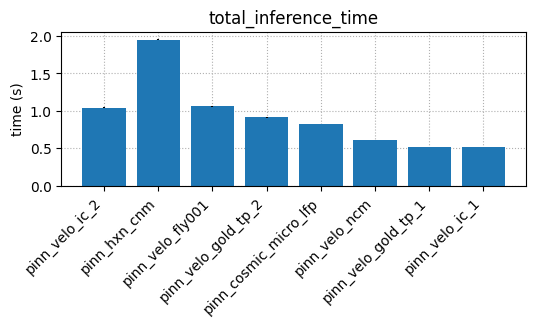

In [10]:
# timing variable vs data name
for var_name in var_names:
    fig, ax = plt.subplots(figsize=(6, 2))
    plt.title(var_name)
    plt.bar(x=data_names, height=averages[var_name], yerr=st_devs[var_name], zorder=2, )
    plt.xticks(rotation=45, ha="right") 
    plt.ylabel("time (s)")
    plt.grid(linestyle=":", zorder=0)
    plt.show()


/tmp/ipykernel_1522235/3876329284.py:47: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


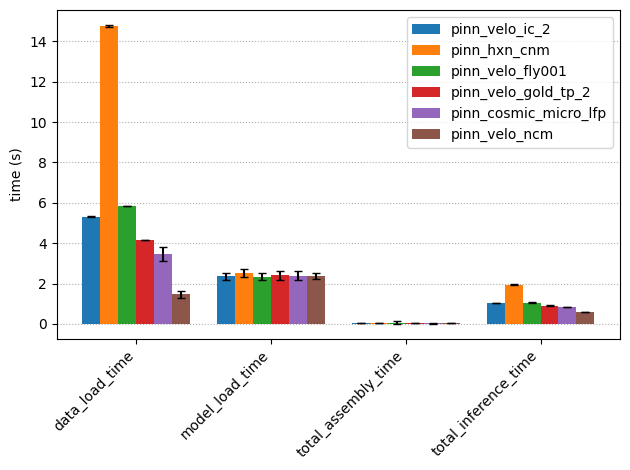

In [ ]:
# Helper to pull values whether averages[var] is list-aligned or dict-keyed
def get_vals_for_data_name(lookup, var_names, data_names, j, data_name):
    vals = []
    for v in var_names:
        arr = lookup[v]
        if isinstance(arr, dict):
            vals.append(arr[data_name])
        else:  # assume list/array aligned with data_names order
            vals.append(arr[j])
    return vals


x = np.arange(len(var_names))
n_d = len(data_names)
bar_w = 0.8 / n_d  # total group width ~0.8

# fig, ax = plt.subplots(figsize=(max(6, 1.5 * len(var_names)), 3.5), layout="compressed")
fig, ax = plt.subplots(layout="compressed")


for j, data_name in enumerate(data_names):
    heights = get_vals_for_data_name(averages, var_names, data_names, j, data_name)
    yerrs = get_vals_for_data_name(st_devs, var_names, data_names, j, data_name)

    # center the group around each x position
    offsets = (j - (n_d - 1) / 2) * bar_w
    ax.bar(
        x + offsets,
        heights,
        width=bar_w,
        label=data_name,
        yerr=yerrs,
        capsize=3,
        zorder=2,
    )

ax.set_xticks(x)
ax.set_xticklabels(var_names, rotation=45, ha="right")
ax.set_ylabel("time (s)")
ax.grid(linestyle=":", zorder=0, axis="y")
# ax.legend(ncol=min(n_d, 4), frameon=False)
ax.legend()
fig.tight_layout()
plt.show()


## pty-chi/ptychodus results

In [9]:
ptychodus_results = {
    "microLFPstack_single_exposure_64": [292.6856, 299.1303],
    "als_64": [63.2154, 64.4192],
    "nxs_data_gold_tp_1_64": [60.0951, 61.4744],
    "nxs_data_gold_tp_2_64": [375.9889, 393.0042],
    "nxs_data_ncm_1_64": [128.4722, 129.9445],
    "nxs_data_ic_2_64": [469.831, 479.0527],
    "nxs_data_ic_1_64": [6.4260, 6.4623],
    "microLFPstack_double_exposure_64": [191.3593, 197.6198],
    "fly001_64": [436.5277, 470.6205],
    "cnmp_xnp_scan39_64", [1088.1014]
}
ptychodus_results = {k:np.mean(v) for k,v in ptychodus_results.items()}

SyntaxError: ':' expected after dictionary key (4166025967.py, line 11)

### documenting errors

2025-08-18 16:33:36,801 [DEBUG] ptychodus.model.diffraction.api: Reading "/local/fly001/fly001_master.h5" as "NPY"
Traceback (most recent call last):
  File "/home/beams/HRUTH/miniforge3/envs/ptychodus/lib/python3.13/site-packages/ptychodus/model/diffraction/api.py", line 124, in open_patterns
    dataset = plugin.strategy.read(file_path)
  File "/home/beams/HRUTH/miniforge3/envs/ptychodus/lib/python3.13/site-packages/ptychodus/plugins/npy_diffraction_file.py", line 27, in read
    data = numpy.load(file_path)
  File "/home/beams/HRUTH/miniforge3/envs/ptychodus/lib/python3.13/site-packages/numpy/lib/_npyio_impl.py", line 489, in load
    raise ValueError(
    ...<2 lines>...
        "`allow_pickle=` keyword argument or `pickle.load()`.")
ValueError: This file contains pickled (object) data. If you trust the file you can load it unsafely using the `allow_pickle=` keyword argument or `pickle.load()`.

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/beams0/HRUTH/code/ptycho_development/PtychoPINN/reconstruct.py", line 41, in <module>
    result = main(settings_file)
  File "/home/beams0/HRUTH/code/ptycho_development/PtychoPINN/reconstruct.py", line 16, in main
    with ModelCore(settings_file, is_developer_mode_enabled=True) as model:
         ~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/beams/HRUTH/miniforge3/envs/ptychodus/lib/python3.13/site-packages/ptychodus/model/core.py", line 189, in __init__
    self.settings_registry.open_settings(settings_file)
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^
  File "/home/beams/HRUTH/miniforge3/envs/ptychodus/lib/python3.13/site-packages/ptychodus/api/settings.py", line 72, in open_settings
    self.notify_observers()
    ~~~~~~~~~~~~~~~~~~~~~^^
  File "/home/beams/HRUTH/miniforge3/envs/ptychodus/lib/python3.13/site-packages/ptychodus/api/observer.py", line 51, in notify_observers
    observer._update(self)
    ~~~~~~~~~~~~~~~~^^^^^^
  File "/home/beams/HRUTH/miniforge3/envs/ptychodus/lib/python3.13/site-packages/ptychodus/model/diffraction/core.py", line 64, in _update
    self.diffraction_api.open_patterns(
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^
        file_path=self.diffraction_settings.file_path.get_value(),
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        file_type=self.diffraction_settings.file_type.get_value(),
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/home/beams/HRUTH/miniforge3/envs/ptychodus/lib/python3.13/site-packages/ptychodus/model/diffraction/api.py", line 126, in open_patterns
    raise RuntimeError(f'Failed to read "{file_path}"') from exc
RuntimeError: Failed to read "/local/fly001/fly001_master.h5"

2025-08-18 17:04:06,682 [DEBUG] ptychodus.model.ptychi.helper: OPR weight smoothing method is None.
2025-08-18 17:04:06,683 [ERROR] ptychodus.model.reconstructor.queue: Reconstructor error!
Traceback (most recent call last):
  File "/home/beams/HRUTH/miniforge3/envs/ptychodus/lib/python3.13/site-packages/ptychodus/model/reconstructor/queue.py", line 88, in _reconstruct
    output_task = input_task.execute()
  File "/home/beams/HRUTH/miniforge3/envs/ptychodus/lib/python3.13/site-packages/ptychodus/model/reconstructor/queue.py", line 62, in execute
    result = self._reconstructor.reconstruct(parameters)
  File "/home/beams/HRUTH/miniforge3/envs/ptychodus/lib/python3.13/site-packages/ptychodus/model/ptychi/lsqml.py", line 180, in reconstruct
    task = PtychographyTask(task_options)
  File "/home/beams/HRUTH/miniforge3/envs/ptychodus/lib/python3.13/site-packages/ptychi/api/task.py", line 79, in __init__
    self.check_options()
    ~~~~~~~~~~~~~~~~~~^^
  File "/home/beams/HRUTH/miniforge3/envs/ptychodus/lib/python3.13/site-packages/ptychi/api/task.py", line 83, in check_options
    self.options.check()
    ~~~~~~~~~~~~~~~~~~^^
  File "/home/beams/HRUTH/miniforge3/envs/ptychodus/lib/python3.13/site-packages/ptychi/api/options/task.py", line 36, in check
    options.check(self)
    ~~~~~~~~~~~~~^^^^^^
  File "/home/beams/HRUTH/miniforge3/envs/ptychodus/lib/python3.13/site-packages/ptychi/api/options/base.py", line 469, in check
    int(ceil((pos_y.max() - pos_y.min() + probe_shape[-2]).item())) + 2,
              ~~~~~~~~~^^
  File "/home/beams/HRUTH/miniforge3/envs/ptychodus/lib/python3.13/site-packages/numpy/_core/_methods.py", line 43, in _amax
    return umr_maximum(a, axis, None, out, keepdims, initial, where)
ValueError: zero-size array to reduction operation maximum which has no identity

### <hr>

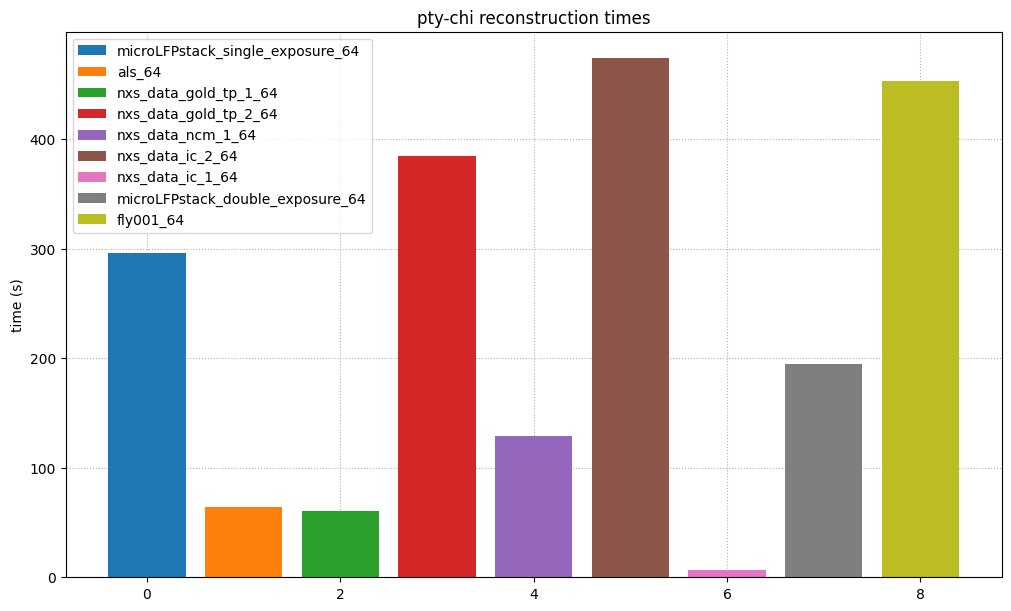

In [4]:
fig, ax = plt.subplots(figsize=(10, 6), layout="compressed")
plt.title("pty-chi reconstruction times")
for i, k in enumerate(ptychodus_results.keys()):
    plt.bar(x=i, height=ptychodus_results[k], zorder=2, label=k)
# plt.legend(loc="outside")
plt.legend()
# plt.xticks(rotation=45, ha="right") 
plt.ylabel("time (s)")
plt.grid(linestyle=":", zorder=0)
plt.show()

In [6]:
folder = "/home/beams/HRUTH/code/ptycho_development/PtychoPINN/"
files = os.listdir(folder)
files = [file for file in files if "64_product.h5" in file]

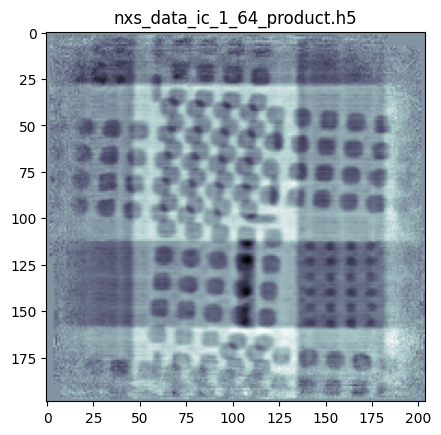

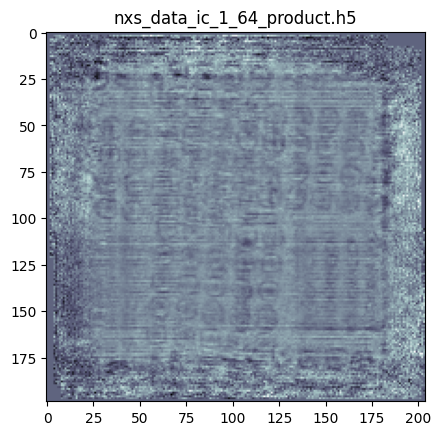

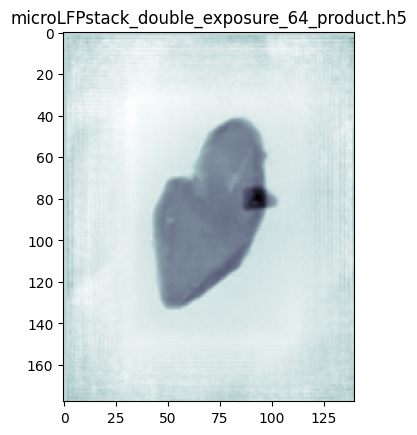

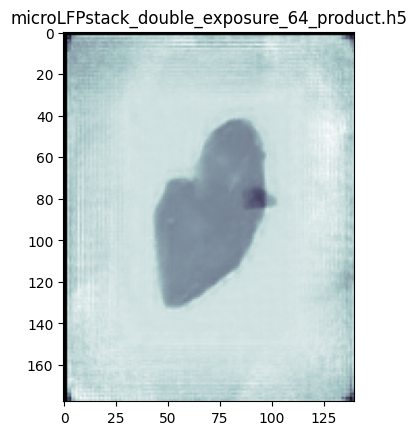

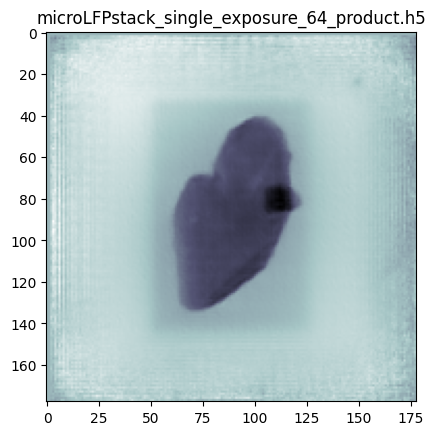

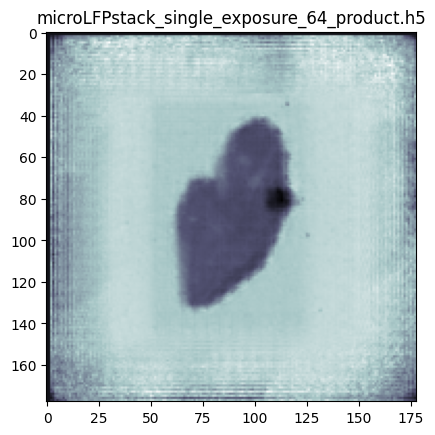

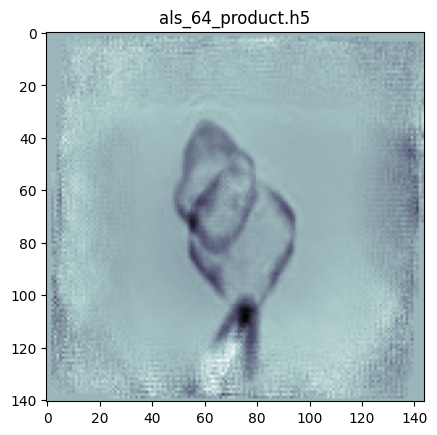

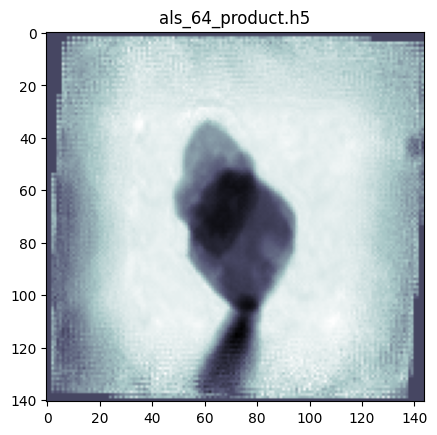

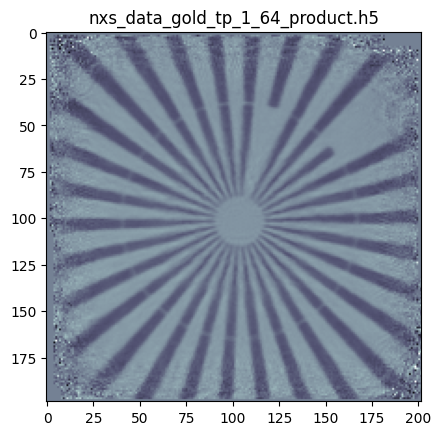

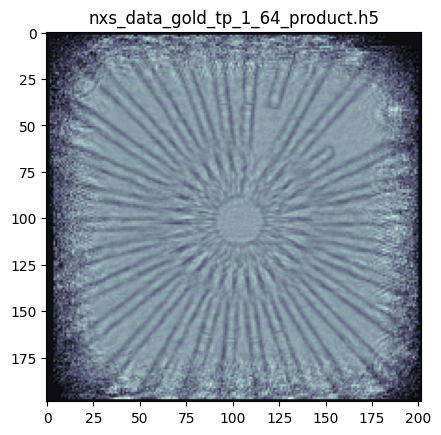

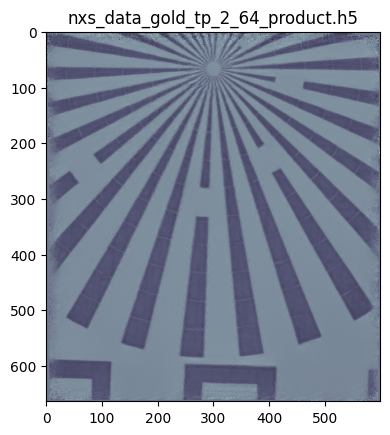

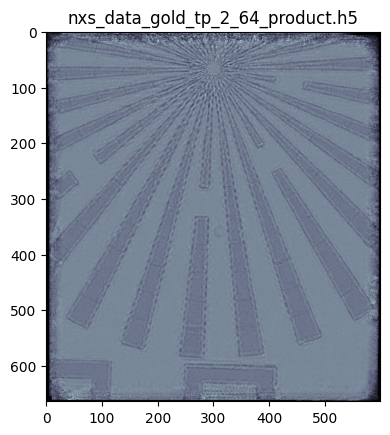

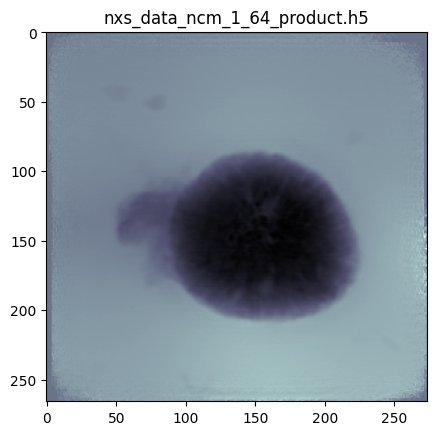

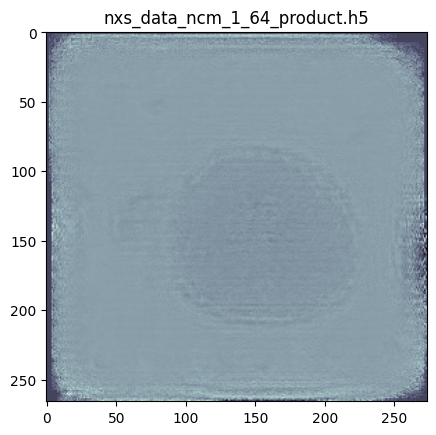

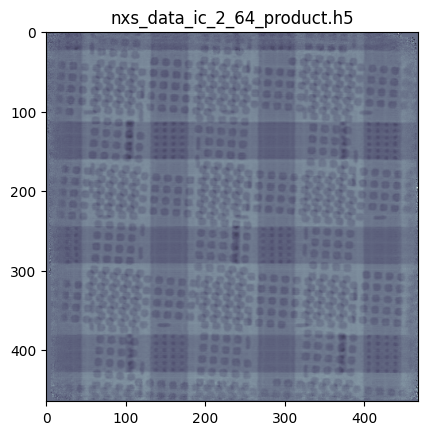

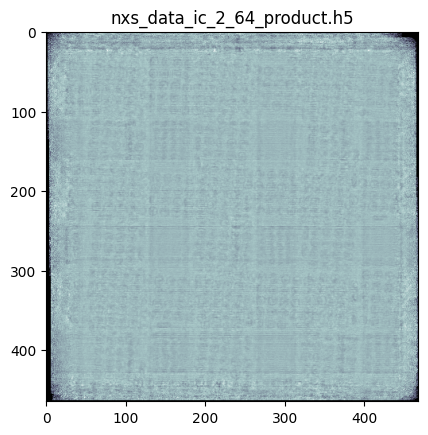

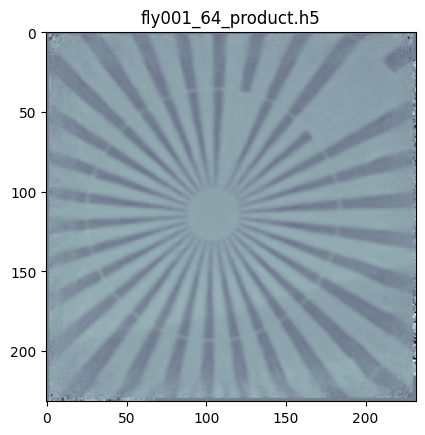

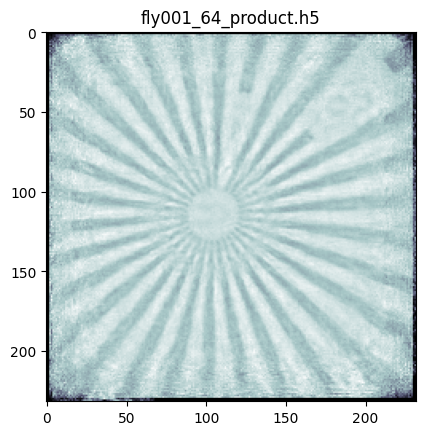

In [7]:
def get_object_and_probe(file_path: str):
    with h5py.File(file_path, "r") as F:
        object_recon = F["object"][()][0]
        probe_recon = F["probe"][()]
    return object_recon, probe_recon
for file in files:
    object_recon, probe_recon = get_object_and_probe(os.path.join(folder, file))
    plt.imshow(np.angle(object_recon), cmap="bone")
    plt.title(file)
    plt.show()
    plt.imshow(np.abs(object_recon), cmap="bone")
    plt.title(file)
    plt.show()
    